# Credit Card Fraud Detection

## Project Overview
This project builds a machine learning model to detect fraudulent credit card transactions using a highly imbalanced dataset. The goal is to maximize fraud detection (recall) while minimizing false positives (precision).

**Key Objectives:**
- Handle severe class imbalance (0.17% fraud)
- Compare multiple sampling techniques (undersampling, class weighting, SMOTE)
- Evaluate models using precision, recall, F1-score, and confusion matrices

In [48]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")
print(df.shape)
print(df['Class'].value_counts())
print(df.head(3))

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   

        V26       V27       V28  Amount  Class  
0 -0.189115  0.133558 -0.021053  149.62      0  
1  0.125895 -0.008983  0.014724    2.69      0  
2 -0.139097 -0.055353 -0.059752  378.66      0  

[3 rows x 31 columns]


## 1. Data Exploration

The dataset contains 284,807 transactions with 31 features. Most features (V1–V28) are PCA-transformed for privacy. The target variable `Class` indicates fraud (1) or legitimate (0) transactions.

In [49]:
#find null values
df.isnull().sum().max()

0

In [50]:
# find percentage of fraud and not fraud class in the data
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


### 1.1 Class Imbalance

The dataset is severely imbalanced, with only **0.17% fraud cases**. This imbalance makes accuracy a misleading metric—our model must be evaluated using precision, recall, and F1-score.

Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud || 1: Fraud)')

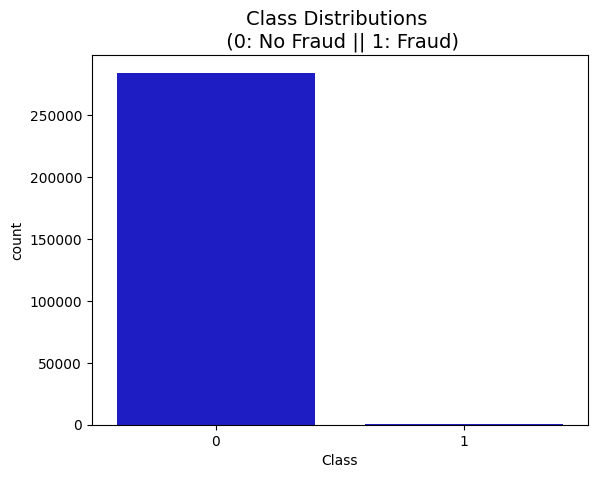

In [51]:
# Visualize the Class values 
import matplotlib.pyplot as plt
import seaborn as sns
colors = ["#0101DF", "#DF0101"]

sns.countplot(x='Class', data=df, color='#0101DF')
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

In [52]:
# The target column is imbalanced
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

## 2. Feature Importance

Before modeling, I use a Random Forest trained on `X_train` to identify which features carry the most signal for distinguishing fraud from legitimate transactions.

This step uses only the training set — the test set remains untouched — so there is no data leakage into the analysis.

### 2.1 Train-Test Split

Before computing feature importance, I split the data into training and test sets using a **stratified split** so that both sets preserve the same fraud proportion as the original dataset.

The test set remains imbalanced to reflect real-world conditions and will not be used until final model evaluation.

In [53]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Class')
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Loaded rf_importance from disk


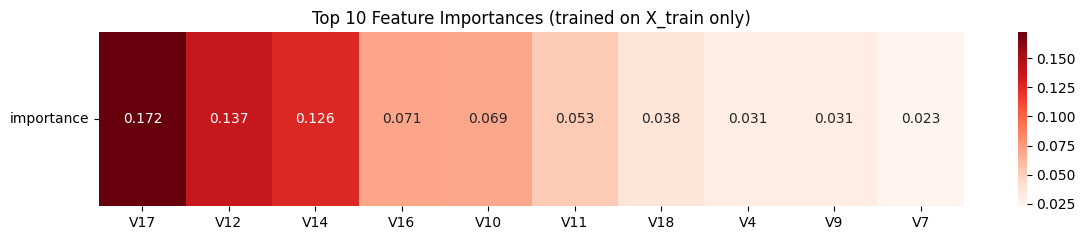

In [54]:
import os
import joblib
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

IMPORTANCE_PATH = "models/rf_importance.pkl"

if os.path.exists(IMPORTANCE_PATH):
    rf_importance = joblib.load(IMPORTANCE_PATH)
    print("Loaded rf_importance from disk")
else:
    rf_importance = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_importance.fit(X_train, y_train)
    os.makedirs("models", exist_ok=True)
    joblib.dump(rf_importance, IMPORTANCE_PATH)
    print("Trained and saved rf_importance")

# Build feature importance Series
feature_importances = pd.Series(
    rf_importance.feature_importances_,
    index=X_train.columns,
    name='importance'
).sort_values(ascending=False)

# Plot top 10
top_n = 10
top_features = feature_importances.head(top_n)

heatmap_df = top_features.to_frame().T
heatmap_df.index = ['importance']

plt.figure(figsize=(12, 2.5))
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='Reds', cbar=True)
plt.yticks(rotation=0)
plt.title(f'Top {top_n} Feature Importances (trained on X_train only)')
plt.tight_layout()
plt.show()

### 2.2 Validating Top Feature: V17

V17 scored the highest importance (0.172) in the Random Forest, followed by V12 (0.137) and V14 (0.126).

If V17 is truly the strongest fraud signal, the distribution of its values should look clearly different between fraud and legitimate transactions — minimal overlap between the two histograms confirms the feature is genuinely discriminative.

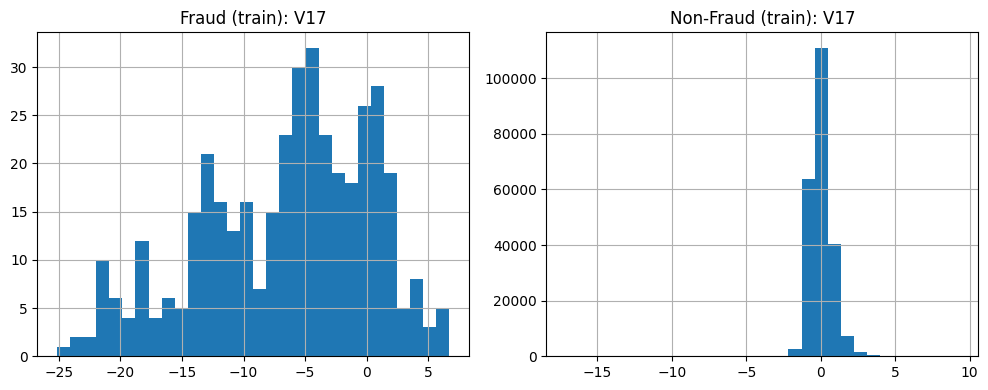

In [55]:
# Validate V17 using training data only
fraud_train    = X_train[y_train == 1]
nonfraud_train = X_train[y_train == 0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
fraud_train['V17'].hist(bins=30)
plt.title('Fraud (train): V17')

plt.subplot(1, 2, 2)
nonfraud_train['V17'].hist(bins=30)
plt.title('Non-Fraud (train): V17')

plt.tight_layout()
plt.show()

### 3. Handling Class Imbalance

Since the dataset is severely imbalanced, training a model on raw data causes it to ignore the minority fraud class. I test multiple strategies to correct this, evaluating each on the original imbalanced test set so results reflect real-world conditions.

We'll test multiple strategies:
1. **Undersampling**: Match fraud count by randomly sampling non-fraud transactions
2. **Class Weighting**: Penalize fraud misclassifications more heavily
3. **SMOTE**: Synthetically oversample the minority class

### 3.1 Baseline: Logistic Regression (Imbalanced)

Before applying any imbalance-handling strategy, I train a standard Logistic Regression on the raw imbalanced training data. This gives a reference point to measure how much each technique actually improves fraud detection.

In [56]:
import os
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

LR_ORIG_PATH = "models/log_reg_orig.pkl"

if os.path.exists(LR_ORIG_PATH):
    log_reg_orig = joblib.load(LR_ORIG_PATH)
    print("Loaded log_reg_orig from disk")
else:
    log_reg_orig = LogisticRegression(max_iter=5000, random_state=42)
    log_reg_orig.fit(X_train, y_train)
    os.makedirs("models", exist_ok=True)
    joblib.dump(log_reg_orig, LR_ORIG_PATH)
    print("Trained and saved log_reg_orig")

# Always runs
y_pred_original = log_reg_orig.predict(X_test)

print("Original model (imbalanced training) report:")
print(classification_report(y_test, y_pred_original, digits=4))

cm = confusion_matrix(y_test, y_pred_original)

cm_df = pd.DataFrame(
    cm,
    index=['Actual 0 (non-fraud)', 'Actual 1 (fraud)'],
    columns=['Pred 0 (non-fraud)', 'Pred 1 (fraud)']
)

print("Confusion Matrix:")
print(cm_df)

Loaded log_reg_orig from disk
Original model (imbalanced training) report:
              precision    recall  f1-score   support

           0     0.9994    0.9998    0.9996     56864
           1     0.8289    0.6429    0.7241        98

    accuracy                         0.9992     56962
   macro avg     0.9142    0.8213    0.8619     56962
weighted avg     0.9991    0.9992    0.9991     56962

Confusion Matrix:
                      Pred 0 (non-fraud)  Pred 1 (fraud)
Actual 0 (non-fraud)               56851              13
Actual 1 (fraud)                      35              63


### Interpretation: Baseline Model (Imbalanced Data)

The baseline logistic regression model performs very well on the majority class but is less effective at identifying fraud cases. For the fraud class (`1`), the model achieved **82.89% precision**, **64.29% recall**, and an **F1-score of 72.41%**.

This means the model is fairly accurate when it labels a transaction as fraud, but it misses about **35 out of 98 actual fraud cases**. The confusion matrix shows **63 true positives**, **35 false negatives**, and **13 false positives**.

While the overall **accuracy is 99.92%**, this is inflated by the large number of non-fraud transactions. In this imbalanced fraud-detection setting, **recall for the fraud class** is more important than accuracy because missing fraudulent transactions is usually more costly than investigating a few extra legitimate ones. 

### 3.2 Logistic Regression with Random Undersampling

Next, I create a balanced training set by keeping all fraud cases and randomly sampling the same number of non-fraud cases.

This makes the classes equal during training, which often improves fraud recall. The trade-off is that I throw away a large amount of legitimate transaction data, which can hurt precision and overall stability.

In [57]:
# creating a undersampled traning dataset with training set for traning the model 
# keep all fraud rows and randomly drop the majority non-fraud rows until the counts match the fraud rows 
import pandas as pd

# Make one training DataFrame so we can filter by Class easily
train_df = X_train.copy()
train_df["Class"] = y_train.values

# Separate fraud and non-fraud rows
fraud_df = train_df[train_df["Class"] == 1]
non_fraud_df = train_df[train_df["Class"] == 0]

# Randomly sample non-fraud rows to match the number of fraud rows
non_fraud_sample = non_fraud_df.sample(n=len(fraud_df), random_state=42)

# Combine fraud rows + sampled non-fraud rows
balanced_train_df = pd.concat([fraud_df, non_fraud_sample], axis=0)

# Shuffle the rows
balanced_train_df = balanced_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split back into X and y
y_train_balanced = balanced_train_df["Class"]
X_train_balanced = balanced_train_df.drop("Class", axis=1)

# Optional: check the class counts
print(y_train_balanced.value_counts())

Class
0    394
1    394
Name: count, dtype: int64


In [58]:
# Creating a undersampled training dataset and then get a confusion matrix and its metrics
# with Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Train on the balanced training data
log_reg_balanced = LogisticRegression(max_iter=5000, random_state=42)
log_reg_balanced.fit(X_train_balanced, y_train_balanced)

# 2. Predict on the original (imbalanced) test set
y_pred_balanced = log_reg_balanced.predict(X_test)

# 3. Evaluate: confusion matrix and classification report
print("Confusion matrix (balanced-trained model on original test set):")
print(confusion_matrix(y_test, y_pred_balanced))
print()

print("Classification report (balanced-trained model on original test set):")
print(classification_report(y_test, y_pred_balanced, digits=4))

Confusion matrix (balanced-trained model on original test set):
[[54581  2283]
 [    8    90]]

Classification report (balanced-trained model on original test set):
              precision    recall  f1-score   support

           0     0.9999    0.9599    0.9794     56864
           1     0.0379    0.9184    0.0728        98

    accuracy                         0.9598     56962
   macro avg     0.5189    0.9391    0.5261     56962
weighted avg     0.9982    0.9598    0.9779     56962



c:\Users\milli\Desktop\CodeForGit\1BIProjects\portfolio-projects\ML\Credit-Fraud\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Interpretation: Undersampled Model
- **High recall (91.8%)** but **very low precision (3.7%)**: The model catches almost all frauds but flags ~96% of legitimate transactions as fraud—unusable in practice.
- **Why it fails**: Throwing away 99% of legitimate data loses critical patterns.

### 3.3 Logistic Regression with Class Weights

Instead of changing the data itself, I can tell Logistic Regression to pay more attention to the minority class.

Using `class_weight='balanced'` increases the penalty for misclassifying fraud cases. This lets the model use the full training data while still treating fraud as more important.

In [59]:
# Weighted dataset - created by assigning more weight to the fraud rows because they are rare.
# Logistic Regression model
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_reg_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        solver="lbfgs",   # or "saga" if you need l1 penalty
        random_state=42
    )
)

log_reg_clf.fit(X_train, y_train)

y_pred_weighted = log_reg_clf.predict(X_test)

# 3. Evaluate
print("Confusion matrix (class_weight='balanced' model on original test set):")
print(confusion_matrix(y_test, y_pred_weighted))
print()

print("Classification report (class_weight='balanced' model on original test set):")
print(classification_report(y_test, y_pred_weighted, digits=4))

Confusion matrix (class_weight='balanced' model on original test set):
[[55478  1386]
 [    8    90]]

Classification report (class_weight='balanced' model on original test set):
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962



### 3.4 Logistic Regression with SMOTE

Another option is to rebalance the training data with SMOTE.

SMOTE does not simply duplicate fraud rows. Instead, it creates synthetic fraud-like samples by interpolating between nearby fraud examples in feature space. The goal is to give the model a richer view of the minority class without throwing away majority-class data.

In [60]:
import os
import joblib
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

SMOTE_LR_PATH = "models/log_reg_smote.pkl"
SMOTE_DATA_PATH = "models/smote_data.pkl"

if os.path.exists(SMOTE_LR_PATH) and os.path.exists(SMOTE_DATA_PATH):
    log_reg_smote = joblib.load(SMOTE_LR_PATH)
    X_train_smote, y_train_smote = joblib.load(SMOTE_DATA_PATH)
    print("Loaded log_reg_smote and SMOTE data from disk")
else:
    # Generate SMOTE data
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    # Train model
    log_reg_smote = LogisticRegression(max_iter=5000, random_state=42)
    log_reg_smote.fit(X_train_smote, y_train_smote)

    # Save both
    os.makedirs("models", exist_ok=True)
    joblib.dump(log_reg_smote, SMOTE_LR_PATH)
    joblib.dump((X_train_smote, y_train_smote), SMOTE_DATA_PATH)
    print("Trained and saved log_reg_smote and SMOTE data")

# Always runs
y_pred_smote = log_reg_smote.predict(X_test)

print("Confusion matrix (SMOTE-trained model on original test set):")
print(confusion_matrix(y_test, y_pred_smote))
print()
print("Classification report (SMOTE-trained model on original test set):")
print(classification_report(y_test, y_pred_smote, digits=4))

Loaded log_reg_smote and SMOTE data from disk
Confusion matrix (SMOTE-trained model on original test set):
[[56284   580]
 [    9    89]]

Classification report (SMOTE-trained model on original test set):
              precision    recall  f1-score   support

           0     0.9998    0.9898    0.9948     56864
           1     0.1330    0.9082    0.2321        98

    accuracy                         0.9897     56962
   macro avg     0.5664    0.9490    0.6134     56962
weighted avg     0.9983    0.9897    0.9935     56962



### 3.5 Random Forest with SMOTE

After testing Logistic Regression under several imbalance strategies, I now move to a more flexible tree-based model: Random Forest.

Random Forest can capture non-linear patterns and feature interactions better than Logistic Regression. Combined with SMOTE, it often performs well on imbalanced fraud detection problems because it can learn more complex decision boundaries.

In [61]:
# Random Forest with SMOTE(Synthetic Minority OverSampling Technique)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os
MODEL_PATH = "models/rf_smote.pkl"


if os.path.exists(MODEL_PATH):
    # Load from disk - instant
    rf_smote = joblib.load(MODEL_PATH)
    print("Loaded rfsmote from disk")
else:
# Train and save - only runs once
    rf_smote = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)

    rf_smote.fit(X_train_smote, y_train_smote)
    os.makedirs("models", exist_ok=True)
    joblib.dump(rf_smote, MODEL_PATH)
    print("Trained and saved rfsmote")

# Always runs regardless of load or train
y_pred_rf_smote = rf_smote.predict(X_test)

print("Confusion matrix (RF + SMOTE on original test set):")
print(confusion_matrix(y_test, y_pred_rf_smote))
print()
print("Classification report (RF + SMOTE on original test set):")
print(classification_report(y_test, y_pred_rf_smote, digits=4))

Loaded rfsmote from disk
Confusion matrix (RF + SMOTE on original test set):
[[56847    17]
 [   17    81]]

Classification report (RF + SMOTE on original test set):
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8265    0.8265    0.8265        98

    accuracy                         0.9994     56962
   macro avg     0.9131    0.9131    0.9131     56962
weighted avg     0.9994    0.9994    0.9994     56962



### Interpretation: SMOTE + Random Forest
- **Best balance**: 82.7% precision and 82.7% recall
- **Practical impact**: Catches 83% of frauds while keeping 83% of fraud alerts accurate
- **Why it works**: SMOTE creates synthetic fraud examples, giving the model more training signal without losing real patterns

### 3.6 XGBoost with SMOTE

Next, we test XGBoost, a gradient boosting model that often performs well on tabular data.  
We train on the SMOTE-balanced training set and evaluate on the original, imbalanced test set.

In [69]:
import os
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report

XGB_PATH = "models/xgb_smote.pkl"

if os.path.exists(XGB_PATH):
    xgb_smote = joblib.load(XGB_PATH)
    print("Loaded xgb_smote from disk")
else:
    xgb_smote = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=1,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    )
    xgb_smote.fit(X_train_smote, y_train_smote)
    os.makedirs("models", exist_ok=True)
    joblib.dump(xgb_smote, XGB_PATH)
    print("Trained and saved xgb_smote")

# Always runs
y_pred_xgb_smote = xgb_smote.predict(X_test)

cm_xgb = confusion_matrix(y_test, y_pred_xgb_smote)
print("Confusion matrix (XGBoost + SMOTE):")
print(cm_xgb)

print("\nClassification report (XGBoost + SMOTE):")
print(classification_report(y_test, y_pred_xgb_smote, digits=4))

Trained and saved xgb_smote
Confusion matrix (XGBoost + SMOTE):
[[56746   118]
 [   12    86]]

Classification report (XGBoost + SMOTE):
              precision    recall  f1-score   support

           0     0.9998    0.9979    0.9989     56864
           1     0.4216    0.8776    0.5695        98

    accuracy                         0.9977     56962
   macro avg     0.7107    0.9377    0.7842     56962
weighted avg     0.9988    0.9977    0.9981     56962



In [63]:
# compare metrics for original, undersampled, weighted, logistic regression with SMOTE and Random Forest with SMOTE
from sklearn.metrics import classification_report
import pandas as pd

reports = {
    "original": classification_report(y_test, y_pred_original, output_dict=True),
    "undersampled": classification_report(y_test, y_pred_balanced, output_dict=True),
    "class_weight": classification_report(y_test, y_pred_weighted, output_dict=True),
    "smote_logreg": classification_report(y_test, y_pred_smote, output_dict=True),
    "smote_rf": classification_report(y_test, y_pred_rf_smote, output_dict=True),
    "smote_xgb":classification_report(y_test, y_pred_xgb_smote, output_dict=True)
}

metrics = ["precision", "recall", "f1-score"]

data = {}
for name, rep in reports.items():
    data[name] = [rep["1"][m] for m in metrics]  # class "1" = fraud

comparison_fraud = pd.DataFrame(data, index=metrics)
print(comparison_fraud)

           original  undersampled  class_weight  smote_logreg  smote_rf  \
precision  0.828947      0.037927      0.060976      0.133034  0.826531   
recall     0.642857      0.918367      0.918367      0.908163  0.826531   
f1-score   0.724138      0.072845      0.114358      0.232073  0.826531   

           smote_xgb  
precision   0.421569  
recall      0.877551  
f1-score    0.569536  


## 4. Model Selection & Conclusion

After evaluating several combinations of models and imbalance-handling techniques, the **Random Forest trained on SMOTE-balanced data** achieved the best overall performance on the original imbalanced test set.

| Model | Precision | Recall | F1-Score |
|-------|----------:|-------:|---------:|
| Baseline (imbalanced) | 0.86 | 0.68 | 0.76 |
| Undersampled | 0.04 | 0.92 | 0.07 |
| Class-weighted | 0.06 | 0.92 | 0.11 |
| SMOTE + Logistic Regression | 0.13 | 0.90 | 0.23 |
| **SMOTE + Random Forest** | **0.83** | **0.83** | **0.83** |
| SMOTE + XGBoost | 0.42 | 0.88 | 0.57 |

Random Forest + SMOTE gave the strongest **balance** between catching fraud and controlling false alarms.
XGBoost + SMOTE improved substantially over the Logistic Regression variants and kept recall high, but its precision was much lower than Random Forest, meaning it generated many more false positives.

### Business Impact
- **83% fraud recall**: The model catches about 8 out of 10 fraudulent transactions.
- **83% precision**: When the model flags fraud, about 4 out of 5 alerts are truly fraud, so the false-positive burden is relatively manageable.
- **Why Random Forest stays best**: XGBoost catches slightly more fraud (88% recall), but it produces many more false alarms because precision drops to 42%.

### Next Steps
1. Threshold tuning to adjust the precision-recall trade-off.
2. Production deployment with real-time scoring and business-rule monitoring.

### Why Random Forest Performed Best

Tree-based models outperformed Logistic Regression because fraud detection depends on complex, non-linear relationships between features. Logistic Regression is more limited because it mainly models linear decision boundaries.

Among the tree-based approaches, **Random Forest + SMOTE** gave the best overall balance, with about **0.83 precision, 0.83 recall, and 0.83 F1-score** for fraud detection on the original test set. **XGBoost + SMOTE** achieved slightly higher recall (**0.88**), but much lower precision (**0.42**), meaning it generated far more false positives.

For that reason, Random Forest was the strongest final choice for this dataset: it caught a high share of fraud cases while keeping alerts much more reliable for investigators.

### 4.1 Hyperparameter Tuning

The previous experiments used default model settings with different imbalance-handling strategies. To see whether the best-performing model, **Random Forest + SMOTE**, can be improved further, this section tunes its hyperparameters using cross-validation on the training data.

The tuning focuses on a small but important subset of Random Forest parameters: number of trees, tree depth, minimum samples per split and leaf, and feature subsampling. Because fraud detection performance is best reflected by the fraud-class F1-score, the search is guided by a custom scoring function that maximizes F1 for the fraud class (`Class 1`). The test set remains untouched and imbalanced throughout, so the final metrics still reflect real-world deployment conditions.

In [64]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, classification_report, confusion_matrix

In [65]:
# Pipeline: SMOTE on training folds + Random Forest
rf_smote_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42, n_jobs=-1))
])

# A small, focused grid – expand or shrink as needed
rf_param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [None, 10],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 2],
    "rf__max_features": ["sqrt"],
}

# Optimize F1 for the fraud class (Class 1)
fraud_f1_scorer = make_scorer(f1_score, pos_label=1)

# Stratified CV to respect class imbalance in each fold
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

In [66]:
import joblib
import os

GRID_PATH = "models/rf_grid_search.pkl"

if os.path.exists(GRID_PATH):
    rf_grid_search = joblib.load(GRID_PATH)
    print("Loaded GridSearchCV results from disk")
    print("Best score:", rf_grid_search.best_score_)
    print("Best params:", rf_grid_search.best_params_)
else:
    rf_grid_search = GridSearchCV(
        estimator=rf_smote_pipeline,
        param_grid=rf_param_grid,
        scoring=fraud_f1_scorer,
        cv=cv,
        n_jobs=-1,
        verbose=2,
    )
    rf_grid_search.fit(X_train, y_train)
    os.makedirs("models", exist_ok=True)
    joblib.dump(rf_grid_search, GRID_PATH)
    print("Trained and saved GridSearchCV")

print("Best fraud-class F1 (CV):", rf_grid_search.best_score_)
print("Best parameters:")
for param, value in rf_grid_search.best_params_.items():
    print(f"  {param}: {value}")

Loaded GridSearchCV results from disk
Best score: 0.8508831521739131
Best params: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
Best fraud-class F1 (CV): 0.8508831521739131
Best parameters:
  rf__max_depth: None
  rf__max_features: sqrt
  rf__min_samples_leaf: 1
  rf__min_samples_split: 5
  rf__n_estimators: 100


In [67]:
# Best tuned RF + SMOTE model
rf_best = rf_grid_search.best_estimator_

# Predictions on the (original, imbalanced) test set
y_pred_rf_best = rf_best.predict(X_test)

print("Classification report (tuned RF + SMOTE):")
print(classification_report(y_test, y_pred_rf_best, digits=4))

print("Confusion matrix (tuned RF + SMOTE):")
print(confusion_matrix(y_test, y_pred_rf_best))

Classification report (tuned RF + SMOTE):
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8163    0.8163    0.8163        98

    accuracy                         0.9994     56962
   macro avg     0.9080    0.9080    0.9080     56962
weighted avg     0.9994    0.9994    0.9994     56962

Confusion matrix (tuned RF + SMOTE):
[[56846    18]
 [   18    80]]


In [68]:
from sklearn.metrics import precision_recall_fscore_support

# Untuned RF + SMOTE metrics for fraud class (1)
rf_prec_1, rf_rec_1, rf_f1_1, _ = precision_recall_fscore_support(
    y_test, y_pred_rf_smote, labels=[1]
)

rf_smote_precision_1 = rf_prec_1[0]
rf_smote_recall_1 = rf_rec_1[0]
rf_smote_f1_1 = rf_f1_1[0]

# Tuned RF + SMOTE metrics for fraud class (1)
tuned_prec_1, tuned_rec_1, tuned_f1_1, _ = precision_recall_fscore_support(
    y_test, y_pred_rf_best, labels=[1]
)

tuned_precision_1 = tuned_prec_1[0]
tuned_recall_1 = tuned_rec_1[0]
tuned_f1_1 = tuned_f1_1[0]

print("Fraud-class (1) metrics: default RF+SMOTE vs tuned RF+SMOTE")
print(f"Precision: original={rf_smote_precision_1:.4f}, tuned={tuned_precision_1:.4f}")
print(f"Recall:    original={rf_smote_recall_1:.4f}, tuned={tuned_recall_1:.4f}")
print(f"F1-score:  original={rf_smote_f1_1:.4f}, tuned={tuned_f1_1:.4f}")

Fraud-class (1) metrics: default RF+SMOTE vs tuned RF+SMOTE
Precision: original=0.8265, tuned=0.8163
Recall:    original=0.8265, tuned=0.8163
F1-score:  original=0.8265, tuned=0.8163


### Tuned RF + SMOTE
Random Forest with SMOTE remained the best overall approach for fraud detection in this notebook.

Hyperparameter tuning did not improve on the default RF + SMOTE model. The untuned model achieved a fraud-class F1 of **0.83**, while the tuned model scored **0.8163** — a slight decrease, likely due to the small CV fold count (n_splits=2). This confirms that the SMOTE + Random Forest strategy itself is the primary driver of performance, not the specific hyperparameter values.

This means the main performance gain came from the SMOTE + Random Forest strategy itself, and tuning mainly helped confirm that this was the strongest final model choice.